In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats
from scipy.linalg import lstsq as sp_lstsq
import warnings
warnings.filterwarnings('ignore')


plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})

DATA = 'dreher_2021_clean_data.xlsx'
print("Setup complete.")

Setup complete.


In [2]:
def fmt(b, se, d=3):
    t = abs(b / se) if se > 0 else 0
    star = '***' if t > 2.576 else ('**' if t > 1.96 else ('*' if t > 1.645 else ''))
    return f'{b:.{d}f}{star}', f'({se:.{d}f})'

def clustered_vcov(X, resid, clusters):
    n, k = X.shape
    g = len(np.unique(clusters))
    meat = np.zeros((k, k))
    for c in np.unique(clusters):
        idx = clusters == c
        Xc = X[idx]; ec = resid[idx]
        meat += (Xc.T @ ec[:, None]) @ (ec[None, :] @ Xc)
    meat *= (g / (g - 1)) * (n - 1) / (n - k)
    try:
        XtXi = np.linalg.inv(X.T @ X)
    except Exception:
        XtXi = np.linalg.pinv(X.T @ X)
    return XtXi @ meat @ XtXi

def re_gls(df, y, xcols, country='iso3', year='year'):
    d = df[[y] + xcols + [country, year]].dropna().copy()
    for c in [y] + xcols:
        d[c] = d[c].astype(float)
    n = len(d)
    g_ids, groups = pd.factorize(d[country])
    G = len(groups)
    k = len(xcols)
    Y = d[y].values
    X = d[xcols].values
    Y_gm = np.array([Y[g_ids == g].mean() for g in range(G)])[g_ids]
    X_gm = np.array([X[g_ids == g].mean(0) for g in range(G)])[g_ids]
    Yw = Y - Y_gm; Xw = X - X_gm
    bw, _, _, _ = sp_lstsq(Xw, Yw)
    eps_w = Yw - Xw @ bw
    sig2_eps = (eps_w @ eps_w) / max(n - G - k, 1)
    Y_b = np.array([Y[g_ids == g].mean() for g in range(G)])
    X_b = np.column_stack([np.array([X[g_ids == g].mean(0) for g in range(G)]), np.ones(G)])
    bb, _, _, _ = sp_lstsq(X_b, Y_b)
    eps_b = Y_b - X_b @ bb
    T_bar = n / G
    sig2_u = max((eps_b @ eps_b) / max(G - k - 1, 1) - sig2_eps / T_bar, 1e-10)
    T_i = np.array([(g_ids == g).sum() for g in range(G)])[g_ids]
    theta = 1 - np.sqrt(sig2_eps / (sig2_eps + T_i * sig2_u))
    Ygls = Y - theta * Y_gm
    Xgls = np.column_stack([X - theta[:, None] * X_gm, (1 - theta)])
    bgls, _, _, _ = sp_lstsq(Xgls, Ygls)
    resid = Y - Xgls @ bgls
    sig2_r = (resid @ resid) / max(n - k - 1, 1)
    vcov = sig2_r * np.linalg.pinv(Xgls.T @ Xgls)
    se = np.sqrt(np.diag(vcov))
    Xorig = np.column_stack([X, np.ones(n)])
    yhat_orig = Xorig @ bgls
    r2_overall = float(np.corrcoef(Y, yhat_orig)[0, 1] ** 2)
    yhat_w = Xw @ bw
    ss_res_w = np.sum((Yw - yhat_w) ** 2)
    ss_tot_w = np.sum((Yw - Yw.mean()) ** 2)
    r2_within = 1 - ss_res_w / ss_tot_w if ss_tot_w > 0 else np.nan
    Y_b_pred = X_b @ bb
    ss_res_b = np.sum((Y_b - Y_b_pred) ** 2)
    ss_tot_b = np.sum((Y_b - Y_b.mean()) ** 2)
    r2_between = 1 - ss_res_b / ss_tot_b if ss_tot_b > 0 else np.nan
    return bgls[:k], se[:k], n, G, r2_overall, r2_within, r2_between

def ols_fe(df, y, xcols, country='iso3', year='year'):
    d = df[[y] + xcols + [country, year]].dropna().copy()
    for c in [y] + xcols:
        d[c] = d[c].astype(float)
    d_dm = d.copy()
    for c in [y] + xcols:
        d_dm[c] -= d_dm.groupby(country)[c].transform('mean')
    yr = pd.get_dummies(d_dm[year], prefix='yr', drop_first=True).astype(float)
    Y = d_dm[y].values
    X = np.column_stack([d_dm[xcols].values, yr.values])
    try:
        beta = np.linalg.solve(X.T @ X, X.T @ Y)
    except Exception:
        beta = np.linalg.lstsq(X, Y, rcond=None)[0]
    resid = Y - X @ beta
    vcov = clustered_vcov(X, resid, d[country].values)
    se = np.sqrt(np.diag(vcov))
    p = len(xcols)
    ss_res = np.sum(resid**2)
    ss_tot = np.sum((Y - Y.mean())**2)
    r2_within = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return beta[:p], se[:p], len(Y), d[country].nunique(), r2_within

def tsls_twoway(df, y, x_endog, x_exog, z_inst, country='iso3', year='year'):

    all_rhs = x_endog + x_exog
    need = [y] + all_rhs + z_inst + [country, year]
    d = df[need].dropna().copy()
    for c in [y] + all_rhs + z_inst:
        d[c] = d[c].astype(float)
    for c in [y] + all_rhs + z_inst:
        d[c] -= d.groupby(country)[c].transform('mean')
    yr = pd.get_dummies(d[year], prefix='yr', drop_first=True).astype(float)
    cl = d[country].values
    n = len(d)
    Y  = d[y].values
    X  = np.column_stack([d[all_rhs].values, yr.values])
    Z  = np.column_stack([d[z_inst + x_exog].values, yr.values])
    ZtZi = np.linalg.pinv(Z.T @ Z)
    Xhat = Z @ ZtZi @ Z.T @ X
    try:
        beta = np.linalg.solve(Xhat.T @ X, Xhat.T @ Y)
    except Exception:
        beta = np.linalg.lstsq(Xhat, Y, rcond=None)[0]
    resid = Y - X @ beta
    vcov  = clustered_vcov(Xhat, resid, cl)
    se    = np.sqrt(np.diag(vcov))
    p     = len(all_rhs)
    Yen = X[:, 0]
    p_ex = len(x_exog)
    Zr = np.column_stack([d[x_exog].values, yr.values]) if p_ex > 0 else yr.values
    Yen_r = Zr @ np.linalg.pinv(Zr.T @ Zr) @ Zr.T @ Yen
    Yen_u = Z  @ ZtZi @ Z.T @ Yen
    sse_r = np.sum((Yen - Yen_r)**2)
    sse_u = np.sum((Yen - Yen_u)**2)
    df_d  = max(n - Z.shape[1], 1)
    cd_f  = ((sse_r - sse_u) / len(z_inst)) / (sse_u / df_d)
    j_pval = np.nan
    if len(z_inst) > len(x_endog):
        e_proj = Z @ ZtZi @ Z.T @ resid
        j_stat = (resid @ e_proj) / (resid @ resid / n)
        j_pval = 1 - stats.chi2.cdf(j_stat, df=len(z_inst) - len(x_endog))
    return beta[:p], se[:p], cd_f, j_pval, n, d[country].nunique()

def ols_firststage(df, y_endog, z_inst, x_exog, country='iso3', year='year'):
    all_x = z_inst + x_exog
    d = df[[y_endog] + all_x + [country, year]].dropna().copy()
    for c in [y_endog] + all_x:
        d[c] = d[c].astype(float)
    for c in [y_endog] + all_x:
        d[c] -= d.groupby(country)[c].transform('mean')
    yr = pd.get_dummies(d[year], prefix='yr', drop_first=True).astype(float)
    Y = d[y_endog].values
    X = np.column_stack([d[all_x].values, yr.values])
    try:
        beta = np.linalg.solve(X.T @ X, X.T @ Y)
    except Exception:
        beta = np.linalg.lstsq(X, Y, rcond=None)[0]
    resid = Y - X @ beta
    vcov = clustered_vcov(X, resid, d[country].values)
    se = np.sqrt(np.diag(vcov))
    p = len(all_x)
    return beta[:p], se[:p]

def simple_ols(Y_arr, X_mat):
    X = np.column_stack([X_mat, np.ones(len(X_mat))])
    b, _, _, _ = sp_lstsq(X, Y_arr)
    resid = Y_arr - X @ b
    n, k = X.shape
    s2 = (resid @ resid) / (n - k)
    se = np.sqrt(np.diag(s2 * np.linalg.pinv(X.T @ X)))
    return b[:-1], se[:-1], n

print("All helper functions loaded successfully.")

All helper functions loaded successfully.


In [3]:
alloc = pd.read_excel(DATA, sheet_name='Allocation', header=3)
alloc.columns = [
    'iso3','year','country','n_of','n_oda','n_oof','amt_of','amt_oda','amt_oof',
    'prob_of','hist_prob','input_factor','fx_reserves','unga','taiwan',
    'trade_log','oil','govt_debt','polity','gdppc_log','pop_log','english','country_id']
for c in alloc.columns[3:]:
    alloc[c] = pd.to_numeric(alloc[c], errors='coerce')

effect = pd.read_excel(DATA, sheet_name='Effectiveness', header=3)
effect.columns = [
    'iso3','year','country','gdp_growth','n_of_t','n_oda_t','n_oof_t',
    'log_of_amt','log_oda_amt','log_oof_amt','of_amt','oda_amt','oof_amt',
    'pop_log','prob_of','input_factor','fx_reserves',
    'iv_input_of','iv_reserves_of','iv_input_oda','iv_reserves_oda',
    'iv_input_oof','iv_reserves_oof',
    'gfcf_log','priv_gfcf_log','consumption_log','hh_consumption_log',
    'gov_consumption_log','savings_log','exports_log','imports_log','fdi_log',
    'dac_oda_log','us_oda_log','ibrd_log','ida_log',
    'govt_surplus','inflation','money_gdp','trade_openness','assassinations','country_id']
for c in effect.columns[3:]:
    effect[c] = pd.to_numeric(effect[c], errors='coerce')

fig2_raw = pd.read_excel(DATA, sheet_name='Physical Inputs (Fig 2)', header=3)
fig2_raw = fig2_raw.apply(pd.to_numeric, errors='coerce')

proj = pd.read_excel(DATA, sheet_name='Project Status (App B1)', header=3)
proj.columns = ['year','status_code','n_projects']
proj = proj.apply(pd.to_numeric, errors='coerce').dropna()

cdf = pd.read_excel(DATA, sheet_name='CDF Projects (App B)', header=3)
cdf.columns = ['year','recipient','region','sector','flow_class','flow_type',
               'proj_status','amount','proj_count','flow_class_code','crs_sector']
cdf['year']   = pd.to_numeric(cdf['year'],   errors='coerce')
cdf['amount'] = pd.to_numeric(cdf['amount'], errors='coerce')

ef = effect.sort_values(['iso3','year']).copy()

for col in ['n_of_t','n_oda_t','n_oof_t','log_of_amt','log_oda_amt','log_oof_amt']:
    ef[f'{col}_lag2'] = ef.groupby('iso3')[col].shift(2)

ef['pop_log_lag1'] = ef.groupby('iso3')['pop_log'].shift(1)

_prob = ef.groupby('iso3')['prob_of'].first()
_prob_oda = ef.groupby('iso3')['prob_of'].first()
_if_by_yr = ef.groupby('year')['input_factor'].first()
_all_yr   = range(int(ef['year'].min()), int(ef['year'].max()) + 1)
_if_ext   = _if_by_yr.reindex(_all_yr).ffill()

def _make_iv_input(df, prob_col='prob_of'):
    out = df['iv_input_of'].copy()
    miss = out.isna()
    yr   = df['year']
    iso  = df['iso3']
    prob_vals = df[prob_col]
    out[miss] = yr[miss].map(_if_ext) * prob_vals[miss]
    return out

ef['iv_input_of_ext']  = _make_iv_input(ef, 'prob_of')
ef['iv_input_oda_ext'] = _make_iv_input(ef, 'prob_of')
ef['iv_input_oof_ext'] = _make_iv_input(ef, 'prob_of')

for col in ['iv_input_of_ext','iv_reserves_of','iv_input_oda_ext','iv_reserves_oda',
            'iv_input_oof_ext','iv_reserves_oof']:
    base = col.replace('_ext','')
    ef[f'{base}_lag3'] = ef.groupby('iso3')[col].shift(3)

for col in ['dac_oda_log','us_oda_log','ibrd_log','ida_log']:
    ef[f'{col}_lag2'] = ef.groupby('iso3')[col].shift(2)
    ef[f'{col}_lag3'] = ef.groupby('iso3')[col].shift(3)

alloc_r = alloc[alloc['year'].between(2000, 2014)].copy()

print(f"Allocation   : {len(alloc_r):,} obs | {alloc_r['iso3'].nunique()} countries | 2000-2014")
print(f"Effectiveness: {len(ef):,} obs | {ef['iso3'].nunique()} countries")
print("Data ready.")

Allocation   : 3,300 obs | 231 countries | 2000-2014
Effectiveness: 13,363 obs | 265 countries
Data ready.


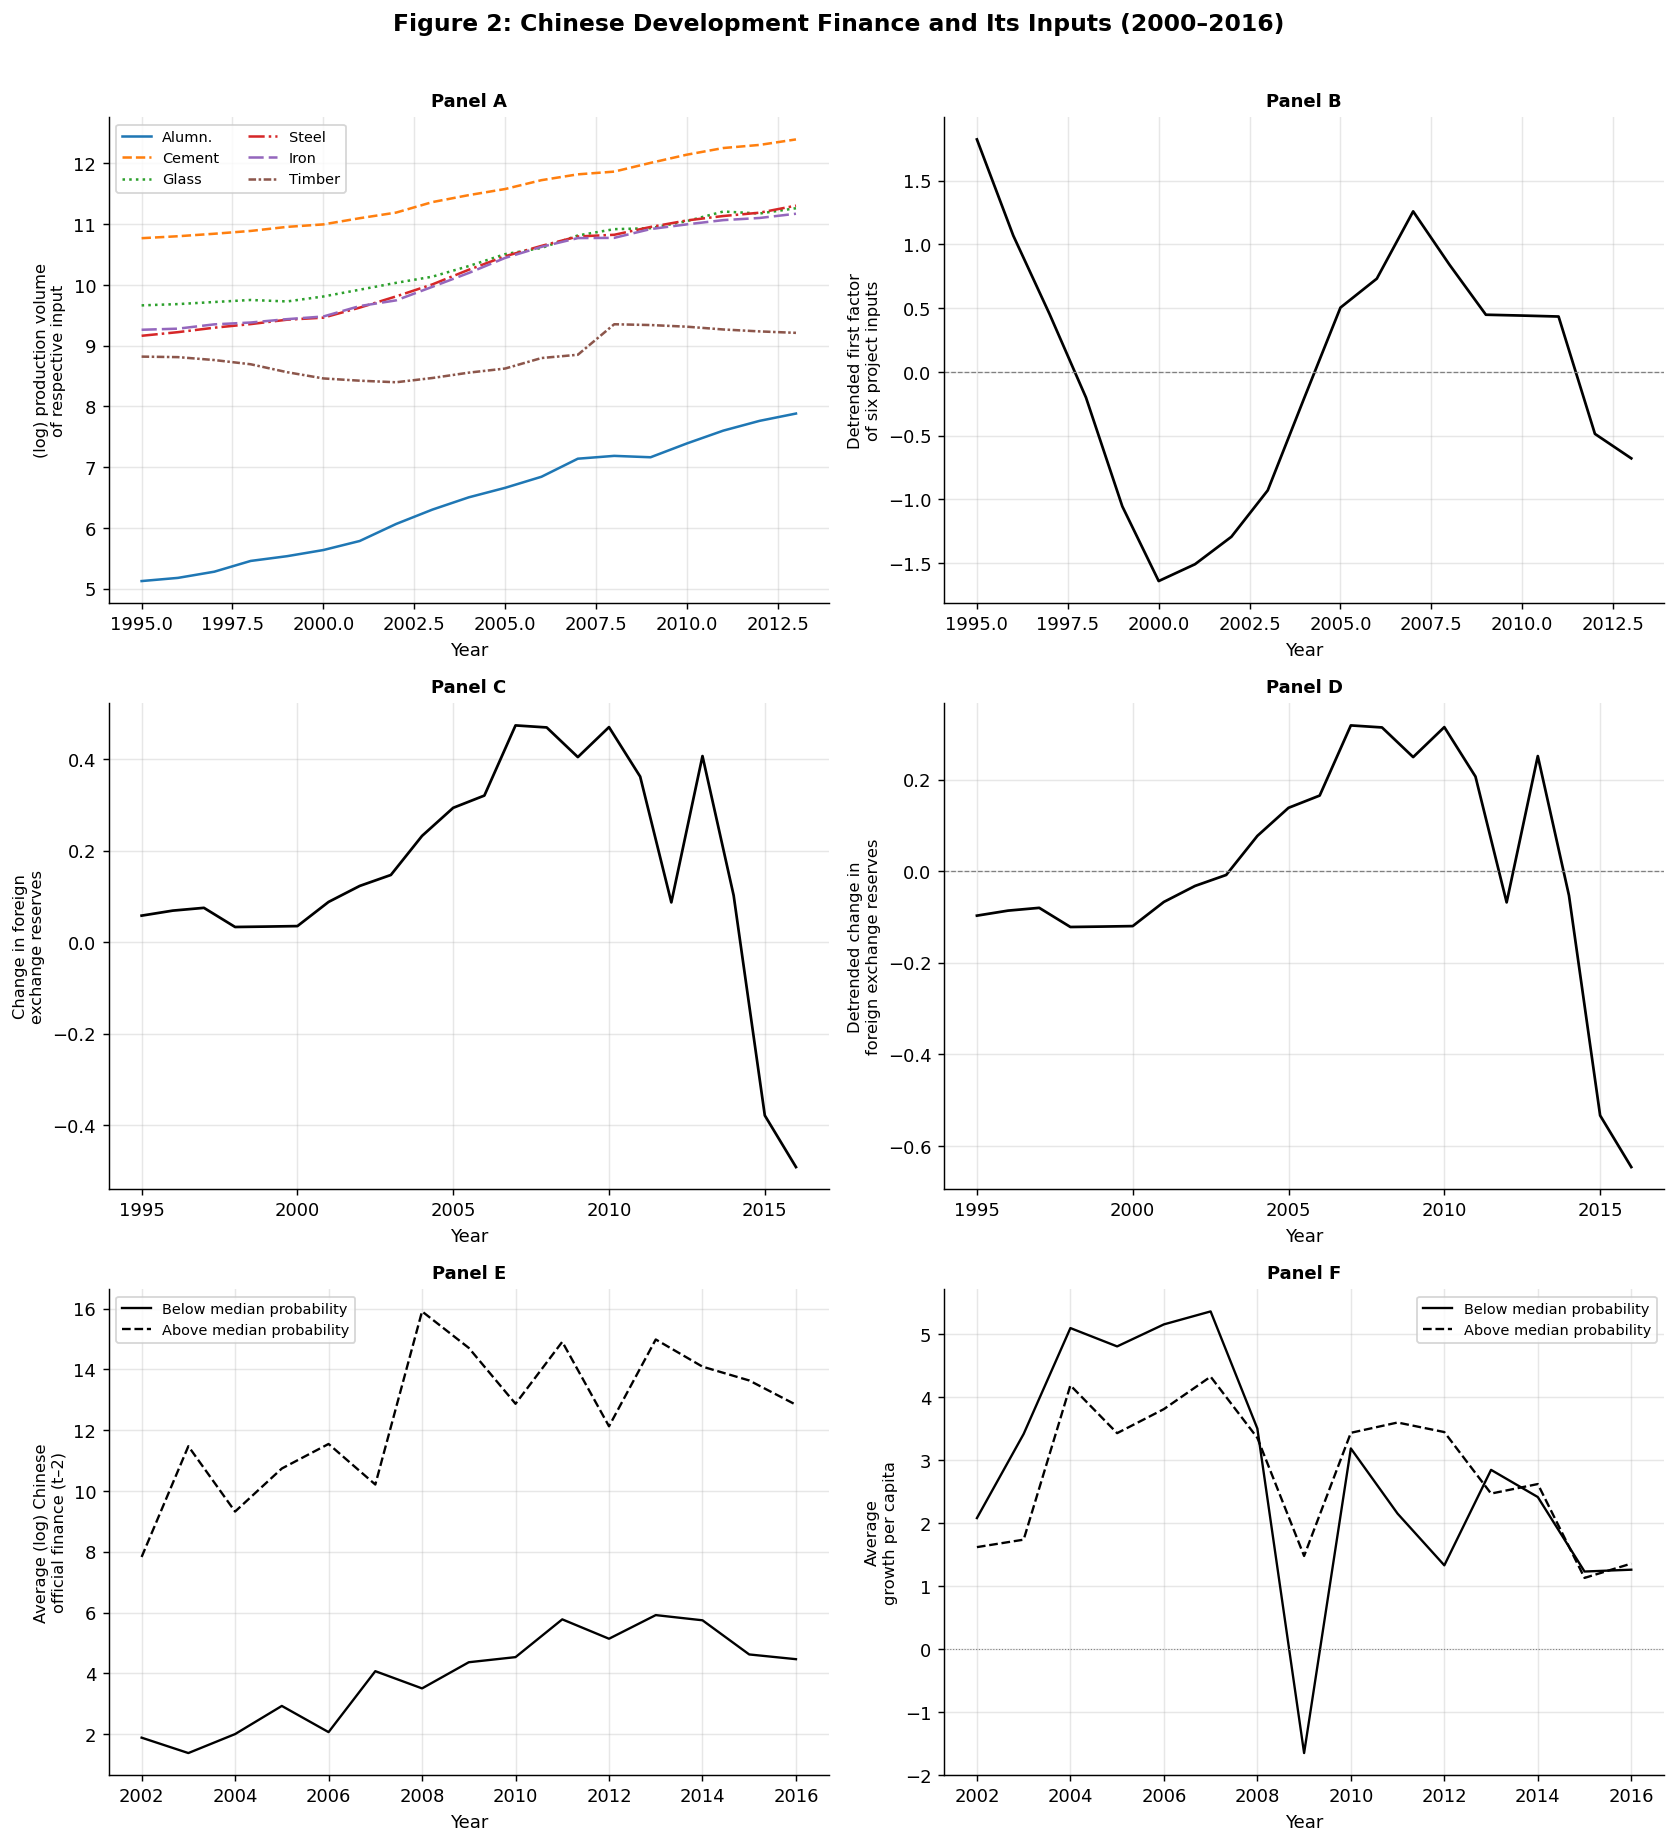

Figure 2 displayed.


In [4]:
def detrend_s(vals, times):
    v = np.asarray(vals, float); t = np.asarray(times, float)
    mask = ~np.isnan(v)
    if mask.sum() < 2: return v
    sl, ic = np.polyfit(t[mask], v[mask], 1)
    return v - (sl * t + ic)

fig2 = fig2_raw.dropna(subset=['Year']).copy()

panel_b_data = ef.groupby('year')['input_factor'].first().dropna().sort_index()   # detrended 1st factor
panel_d_data = ef.groupby('year')['fx_reserves'].first().dropna().sort_index()    # detrended FX

panel_c_data = panel_d_data + 0.155

ef_f2 = ef.copy()
ef_f2['log_of_lag2_f2'] = ef_f2.groupby('iso3')['log_of_amt'].shift(2)   # compute on FULL ef

ef_reg = ef_f2[ef_f2['year'].between(2002, 2016)]
sample_ctry = ef_reg.dropna(subset=['gdp_growth','n_of_t_lag2',
                                     'iv_input_of_lag3','iv_reserves_of_lag3',
                                     'pop_log_lag1'])['iso3'].unique()

ef_fig = ef_f2[ef_f2['year'].between(2002, 2016) & ef_f2['iso3'].isin(sample_ctry)].copy()
med_p  = ef_fig.dropna(subset=['prob_of'])['prob_of'].median()
ef_fig['grp'] = np.where(ef_fig['prob_of'] > med_p,
                          'Above median probability', 'Below median probability')
panel_e = ef_fig.groupby(['year','grp'])['log_of_lag2_f2'].mean().unstack()
panel_f = ef_fig.groupby(['year','grp'])['gdp_growth'].mean().unstack()

fig, axes = plt.subplots(3, 2, figsize=(13, 14))
fig.suptitle('Figure 2: Chinese Development Finance and Its Inputs (2000–2016)',
             fontsize=13, fontweight='bold', y=1.01)

ax = axes[0, 0]
col_map = [
    ('ln(Aluminum)','Alumn.','-','#1f77b4'),
    ('ln(Cement)', 'Cement','--','#ff7f0e'),
    ('ln(Glass)','Glass',':','#2ca02c'),
    ('ln(Steel)','Steel','-.','#d62728'),
    ('ln(Iron)','Iron',(0,(6,2)),'#9467bd'),
    ('ln(Timber)','Timber',  (0,(3,1,1,1)),'#8c564b'),
]
for col, lbl, ls, cl in col_map:
    sub = fig2.dropna(subset=[col])
    ax.plot(sub['Year'], sub[col], linestyle=ls, color=cl, label=lbl, lw=1.4)
ax.set_ylabel('(log) production volume\nof respective input', fontsize=9)
ax.set_title('Panel A', fontsize=10, fontweight='bold')
ax.legend(fontsize=8, ncol=2); ax.set_xlabel('Year')

ax = axes[0, 1]
ax.plot(panel_b_data.index, panel_b_data.values, color='black', lw=1.5)
ax.axhline(0, color='gray', lw=0.7, ls='--')
ax.set_ylabel('Detrended first factor\nof six project inputs', fontsize=9)
ax.set_title('Panel B', fontsize=10, fontweight='bold'); ax.set_xlabel('Year')

ax = axes[1, 0]
ax.plot(panel_c_data.index, panel_c_data.values, color='black', lw=1.5)
ax.set_ylabel('Change in foreign\nexchange reserves', fontsize=9)
ax.set_title('Panel C', fontsize=10, fontweight='bold'); ax.set_xlabel('Year')

ax = axes[1, 1]
ax.plot(panel_d_data.index, panel_d_data.values, color='black', lw=1.5)
ax.axhline(0, color='gray', lw=0.7, ls='--')
ax.set_ylabel('Detrended change in\nforeign exchange reserves', fontsize=9)
ax.set_title('Panel D', fontsize=10, fontweight='bold'); ax.set_xlabel('Year')

g_styles = {'Below median probability': '-', 'Above median probability': '--'}
for pdata, ax, ylabel, title in [
    (panel_e, axes[2, 0], 'Average (log) Chinese\nofficial finance (t–2)', 'Panel E'),
    (panel_f, axes[2, 1], 'Average\ngrowth per capita',                    'Panel F'),
]:
    for grp, ls in g_styles.items():
        if grp in pdata.columns:
            sub = pdata[grp].dropna()
            ax.plot(sub.index, sub.values, ls=ls, color='black', label=grp, lw=1.3)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8); ax.set_xlabel('Year')
    if title == 'Panel F':
        ax.axhline(0, color='gray', lw=0.6, ls=':')

plt.tight_layout()
plt.show()
print('Figure 2 displayed.')


In [5]:
BASE  = ['unga','taiwan','trade_log','oil','govt_debt','polity','gdppc_log','pop_log','english']
BASE2 = ['unga','taiwan','trade_log',      'govt_debt','polity','gdppc_log','pop_log','english']

SPECS_T1 = [
    (['input_factor'] + BASE,'RE'),
    (['input_factor','fx_reserves']+ BASE,'RE'),
    (['input_factor','hist_prob']+ BASE,'RE'),
    (['input_factor','prob_of']+ BASE,'RE'),
    (['prob_of']+ BASE,  'RE'),
    (['input_factor','hist_prob']+ BASE2,'FE'),
    (['input_factor','prob_of']+ BASE2,'FE'),
]

res_t1 = []
for xcols, model in SPECS_T1:
    xcols = [c for c in xcols if c in alloc_r.columns]
    try:
        if model == 'RE':
            b, se, n, G, r2_ov, r2_wi, r2_be = re_gls(alloc_r, 'n_of', xcols)
            res_t1.append({'xcols':xcols,'beta':b,'se':se,'n':n,'G':G,
                           'r2_ov':r2_ov,'r2_wi':r2_wi,'r2_be':r2_be,'model':model})
        else:
            b, se, n, G, r2_wi = ols_fe(alloc_r, 'n_of', xcols)
            res_t1.append({'xcols':xcols,'beta':b,'se':se,'n':n,'G':G,
                           'r2_ov':np.nan,'r2_wi':r2_wi,'r2_be':np.nan,'model':model})
    except Exception as ex:
        res_t1.append({'xcols':xcols,'beta':[np.nan]*len(xcols),
                       'se':[np.nan]*len(xcols),'n':0,'G':0,
                       'r2_ov':np.nan,'r2_wi':np.nan,'r2_be':np.nan,'model':model})
        print(f'  Error ({model}): {ex}')

print(f'Table 1 complete: {len(res_t1)} models')

Table 1 complete: 7 models


In [6]:
VAR_LBL = {
    'input_factor': 'Input factors (t-1)',
    'fx_reserves':  'Reserves (t-1)',
    'hist_prob':    'OF probability, historic',
    'prob_of':      'OF probability, contemp.',
    'unga':         'UNGA voting alignment',
    'taiwan':       'Diplomatic relations Taiwan',
    'trade_log':    'Trade with China (log)',
    'oil':          'Petroleum exporter',
    'govt_debt':    'Government debt (percent of GDP)',
    'polity':       'Democracy (polity score)',
    'gdppc_log':    'GDP per capita (log)',
    'pop_log':      'Population (log)',
    'english':      'English is official language',
}
KEY_ORDER = list(VAR_LBL.keys())
COL_N = [f'({i+1})' for i in range(7)]
W = 14

sep = '=' * (40 + 7*W)
print(sep)
print('Table 1 — Allocation of Chinese Official Financing I (2000–2014)')
print('Dependent variable: Number of Chinese government-financed projects in country-year')
print('Columns 1–5: Random Effects (Swamy-Arora GLS).  Columns 6–7: Country Fixed Effects.')
print(sep)
print(f"  {'Variable':<38}" + ''.join([f'{c:>{W}}' for c in COL_N]))
print('-' * (40 + 7*W))

for var in KEY_ORDER:
    coefs = []; ses = []
    for res in res_t1:
        if var in res['xcols']:
            idx = res['xcols'].index(var)
            b, se = res['beta'][idx], res['se'][idx]
            bc, sc = fmt(b, se) if not np.isnan(b) else ('', '')
        else:
            bc, sc = '', ''
        coefs.append(bc); ses.append(sc)
    print(f"  {VAR_LBL[var]:<38}" + ''.join([f'{c:>{W}}' for c in coefs]))
    if any(s for s in ses):
        print(f"  {'':38}" + ''.join([f'{s:>{W}}' for s in ses]))

print('-' * (40 + 7*W))
print(f"  {'Observations':<38}" + ''.join([f"{r['n']:>{W}}" for r in res_t1]))
print(f"  {'Number of countries':<38}" + ''.join([f"{r['G']:>{W}}" for r in res_t1]))
r2_ov_row = [f"{r['r2_ov']:.2f}" if not np.isnan(r['r2_ov']) else '' for r in res_t1]
r2_wi_row = [f"{r['r2_wi']:.2f}" if not np.isnan(r['r2_wi']) else '' for r in res_t1]
r2_be_row = [f"{r['r2_be']:.2f}" if not np.isnan(r['r2_be']) else '' for r in res_t1]
print(f"  {'R² (overall)':<38}" + ''.join([f'{v:>{W}}' for v in r2_ov_row]))
print(f"  {'R² (within)':<38}"  + ''.join([f'{v:>{W}}' for v in r2_wi_row]))
print(f"  {'R² (between)':<38}" + ''.join([f'{v:>{W}}' for v in r2_be_row]))
print(sep)
print('Notes: *p<0.10, **p<0.05, ***p<0.01.  Standard errors in parentheses.')
print('Abbreviations: OF—official finance. UNGA—United Nations General Assembly.')

Table 1 — Allocation of Chinese Official Financing I (2000–2014)
Dependent variable: Number of Chinese government-financed projects in country-year
Columns 1–5: Random Effects (Swamy-Arora GLS).  Columns 6–7: Country Fixed Effects.
  Variable                                         (1)           (2)           (3)           (4)           (5)           (6)           (7)
------------------------------------------------------------------------------------------------------------------------------------------
  Input factors (t-1)                         0.381***         0.253      0.388***      0.357***                    0.646***      0.646***
                                               (0.104)       (0.168)       (0.101)       (0.096)                     (0.209)       (0.209)
  Reserves (t-1)                                               1.026                                                                      
                                                             (1.053)     

In [7]:
ts = alloc_r.groupby('year').agg(
    n_of_total=('n_of','sum'),
    unga=('unga','mean'),
    pop_log=('pop_log','mean'),
    input_factor=('input_factor','first'),
    fx_reserves=('fx_reserves','first')
).reset_index()

ts1 = ts.dropna(subset=['n_of_total','input_factor','unga','pop_log'])
b1, se1, n1 = simple_ols(ts1['n_of_total'].values,
                          ts1[['input_factor','unga','pop_log']].values)

ts2 = ts.dropna(subset=['n_of_total','fx_reserves','unga','pop_log'])
b2, se2, n2 = simple_ols(ts2['n_of_total'].values,
                          ts2[['fx_reserves','unga','pop_log']].values)

xs_vars = ['n_of','unga','taiwan','trade_log','oil','govt_debt','polity',
           'gdppc_log','pop_log','english','hist_prob','prob_of']
xs = alloc_r.groupby('iso3')[xs_vars].mean().reset_index()
xs['n_of_total'] = alloc_r.groupby('iso3')['n_of'].sum().values

xs_controls = ['unga','taiwan','trade_log','oil','govt_debt','polity','gdppc_log','pop_log','english']

xs3 = xs.dropna(subset=['n_of_total','hist_prob'] + xs_controls)
b3, se3, n3 = simple_ols(xs3['n_of_total'].values,
                          xs3[['hist_prob'] + xs_controls].values)

xs4 = xs.dropna(subset=['n_of_total','prob_of'] + xs_controls)
b4, se4, n4 = simple_ols(xs4['n_of_total'].values,
                          xs4[['prob_of'] + xs_controls].values)

W = 14
sep = '=' * (40 + 4*W)
print(sep)
print('Table 2 — Allocation of Chinese Official Financing II (2000–2014)')
print('Cols 1-2: Time series (N=15 years).  Cols 3-4: Cross-section (N≈125 countries).')
print(sep)
print(f"  {'Variable':<38}" + ''.join([f'{c:>{W}}' for c in ['(1)','(2)','(3)','(4)']]))
print('-' * (40 + 4*W))

rows2 = [
    ('Input factors (t-1)',        [b1[0], None,  None,  None ],  [se1[0],None,  None,  None  ]),
    ('Reserves (t-1)',             [None,  b2[0], None,  None ],  [None,  se2[0],None,  None  ]),
    ('OF probability, historic',   [None,  None,  b3[0], None ],  [None,  None,  se3[0],None  ]),
    ('OF probability, contemp.',   [None,  None,  None,  b4[0]],  [None,  None,  None,  se4[0]]),
    ('UNGA voting alignment',      [b1[1], b2[1], b3[1+len(xs_controls)-len(xs_controls)], b4[1+len(xs_controls)-len(xs_controls)]],
                                   [se1[1],se2[1],se3[1], se4[1]]),
    ('Diplomatic relations Taiwan',[None,  None,  b3[2], b4[2]],  [None,  None,  se3[2],se4[2]]),
    ('Trade with China (log)',     [None,  None,  b3[3], b4[3]],  [None,  None,  se3[3],se4[3]]),
    ('Petroleum exporter',         [None,  None,  b3[4], b4[4]],  [None,  None,  se3[4],se4[4]]),
    ('Government debt (% of GDP)', [None,  None,  b3[5], b4[5]],  [None,  None,  se3[5],se4[5]]),
    ('Democracy (polity score)',   [None,  None,  b3[6], b4[6]],  [None,  None,  se3[6],se4[6]]),
    ('GDP per capita (log)',       [None,  None,  b3[7], b4[7]],  [None,  None,  se3[7],se4[7]]),
    ('Population (log)',           [b1[2], b2[2], b3[8], b4[8]],  [se1[2],se2[2],se3[8],se4[8]]),
    ('English is official language',[None, None,  b3[9], b4[9]],  [None,  None,  se3[9],se4[9]]),
]

for lbl, bvs, sevs in rows2:
    coefs = [fmt(b,se)[0] if b is not None and not np.isnan(b) else '' for b,se in zip(bvs,sevs)]
    sess  = [fmt(b,se)[1] if b is not None and not np.isnan(b) else '' for b,se in zip(bvs,sevs)]
    print(f'  {lbl:<38}' + ''.join([f'{c:>{W}}' for c in coefs]))
    if any(s for s in sess):
        print(f"  {'':38}" + ''.join([f'{s:>{W}}' for s in sess]))

def r2_ols(Y, X_mat):
    X = np.column_stack([X_mat, np.ones(len(X_mat))])
    b, _, _, _ = sp_lstsq(X, Y)
    yhat = X @ b
    return float(np.corrcoef(Y, yhat)[0, 1] ** 2)

r2_1 = r2_ols(ts1['n_of_total'].values, ts1[['input_factor','unga','pop_log']].values)
r2_2 = r2_ols(ts2['n_of_total'].values, ts2[['fx_reserves','unga','pop_log']].values)
r2_3 = r2_ols(xs3['n_of_total'].values, xs3[['hist_prob'] + xs_controls].values)
r2_4 = r2_ols(xs4['n_of_total'].values, xs4[['prob_of']  + xs_controls].values)

print('-' * (40 + 4*W))
print(f"  {'Observations':<38}" + ''.join([f'{n:>{W}}' for n in [n1,n2,n3,n4]]))
r2_strs = [f'{r:.2f}' for r in [r2_1,r2_2,r2_3,r2_4]]
print(f"  {'R2 (within/overall)':<38}" + ''.join([f'{v:>{W}}' for v in r2_strs]))
print(sep)
print('Notes: Each column is one OLS regression. *p<0.10, **p<0.05, ***p<0.01.')

Table 2 — Allocation of Chinese Official Financing II (2000–2014)
Cols 1-2: Time series (N=15 years).  Cols 3-4: Cross-section (N≈125 countries).
  Variable                                         (1)           (2)           (3)           (4)
------------------------------------------------------------------------------------------------
  Input factors (t-1)                        36.678***                                          
                                              (10.423)                                          
  Reserves (t-1)                                          205.069***                            
                                                            (75.531)                            
  OF probability, historic                                               41.318***              
                                                                          (11.621)              
  OF probability, contemp.                                                    

In [8]:
ef3 = ef[ef['year'].between(2002, 2016)].copy()

COLS_T3 = [
    # (OF_var_at_t-2, input_instrument_at_t-3, reserves_instrument_at_t-3, label)
    ('n_of_t_lag2',      'iv_input_of_lag3',   'iv_reserves_of_lag3',   'All projects'),
    ('n_oof_t_lag2',     'iv_input_oof_lag3',  'iv_reserves_oof_lag3',  'OOF projects'),
    ('n_oda_t_lag2',     'iv_input_oda_lag3',  'iv_reserves_oda_lag3',  'ODA projects'),
    ('log_of_amt_lag2',  'iv_input_of_lag3',   'iv_reserves_of_lag3',   '(log) All amounts'),
    ('log_oof_amt_lag2', 'iv_input_oof_lag3',  'iv_reserves_oof_lag3',  '(log) OOF amounts'),
    ('log_oda_amt_lag2', 'iv_input_oda_lag3',  'iv_reserves_oda_lag3',  '(log) ODA amounts'),
]

ols_t3 = []; tsls_t3 = []; rf_t3 = []; fs_t3 = []
for of_var, iv_in, iv_res, lbl in COLS_T3:
    try:
        b, se, n, G, _ = ols_fe(ef3, 'gdp_growth', [of_var, 'pop_log_lag1'])
        ols_t3.append({'lbl':lbl,'b':b,'se':se,'n':n,'G':G})
    except:
        ols_t3.append({'lbl':lbl,'b':[np.nan,np.nan],'se':[np.nan,np.nan],'n':0,'G':0})
    try:
        b_rf, se_rf, n_rf, G_rf, _ = ols_fe(ef3, 'gdp_growth', [iv_in, iv_res, 'pop_log_lag1'])
        rf_t3.append({'lbl':lbl,'b':b_rf,'se':se_rf,'n':n_rf,'G':G_rf})
    except:
        rf_t3.append({'lbl':lbl,'b':[np.nan]*3,'se':[np.nan]*3,'n':0,'G':0})
    try:
        b2, se2, cd_f, j_pv, n2, G2 = tsls_twoway(
            ef3, 'gdp_growth', x_endog=[of_var], x_exog=['pop_log_lag1'],
            z_inst=[iv_in, iv_res])
        tsls_t3.append({'lbl':lbl,'b':b2,'se':se2,'cd_f':cd_f,'j_pv':j_pv,'n':n2,'G':G2})
    except Exception as ex:
        tsls_t3.append({'lbl':lbl,'b':[np.nan,np.nan],'se':[np.nan,np.nan],
                        'cd_f':np.nan,'j_pv':np.nan,'n':0,'G':0})
    try:
        b_fs, se_fs = ols_firststage(ef3, of_var,
                                      z_inst=[iv_in, iv_res],
                                      x_exog=['pop_log_lag1'])
        fs_t3.append({'lbl':lbl,'b':b_fs,'se':se_fs})
    except:
        fs_t3.append({'lbl':lbl,'b':[np.nan]*3,'se':[np.nan]*3})

print('Table 3 regressions complete.')

Table 3 regressions complete.


In [9]:
W = 14
hdr = ['(1)','(2)','(3)','(4)','(5)','(6)']
sublbls = ['All\nprojects','OOF\nprojects','ODA\nprojects',
           '(log) All\namounts','(log) OOF\namounts','(log) ODA\namounts']
sep = '=' * (38 + 6*W)

print(sep)
print('Table 3 — Growth Effects of Chinese Official Financing, Baseline Results (2002–2016)')
print('Dependent variable: GDP per capita growth')
print(sep)
print(f"  {'':36}" + ''.join([f'{h:>{W}}' for h in hdr]))

def prow(results, idx, label):
    coefs=[]; ses=[]
    for r in results:
        if idx < len(r['b']):
            b, se = r['b'][idx], r['se'][idx]
        else:
            b, se = np.nan, np.nan
        if np.isnan(b): coefs.append(''); ses.append('')
        else:
            bc, sc = fmt(b,se); coefs.append(bc); ses.append(sc)
    print(f'  {label:<36}' + ''.join([f'{c:>{W}}' for c in coefs]))
    print(f"  {'':36}" + ''.join([f'{s:>{W}}' for s in ses]))

print('\n  Panel A. OLS estimates — Dependent variable: GDP per capita growth')
prow(ols_t3, 0, 'Chinese OF (t-2)')
prow(ols_t3, 1, '(log) population (t-1)')

print('\n  Panel B. Reduced-form estimates — Dependent variable: GDP per capita growth')
prow(rf_t3, 0, 'Input (t-3) × probability')
prow(rf_t3, 1, 'Reserves (t-3) × probability')
prow(rf_t3, 2, '(log) population (t-1)')

print('\n  Panel C. 2SLS estimates — Dependent variable: GDP per capita growth')
prow(tsls_t3, 0, 'Chinese OF (t-2)')
prow(tsls_t3, 1, '(log) population (t-1)')

print('\n  Panel D. First-stage estimates — Dependent variable: Chinese OF (t-2)')
prow(fs_t3, 0, 'Input (t-3) × probability')
prow(fs_t3, 1, 'Reserves (t-3) × probability')
prow(fs_t3, 2, '(log) population (t-1)')

print('-' * (38 + 6*W))
print(f"  {'Number of countries':<36}" + ''.join([f"{r['G']:>{W}}" for r in tsls_t3]))
print(f"  {'Observations':<36}"        + ''.join([f"{r['n']:>{W}}" for r in tsls_t3]))
print(f"  {'Cragg-Donald F-statistic':<36}" + ''.join(
    [f"{r['cd_f']:>{W}.2f}" if not np.isnan(r['cd_f']) else f"{'—':>{W}}" for r in tsls_t3]))
jpvs = [f"{r['j_pv']:>{W}.2f}" if not np.isnan(r['j_pv']) else f"{'—':>{W}}" for r in tsls_t3]
print(f"  {'Hansen J-statistic (p-value)':<36}" + ''.join(jpvs))
print(sep)
print('Notes: Country and year fixed effects in all regressions.')
print('Standard errors clustered at country level. *p<0.10, **p<0.05, ***p<0.01.')

Table 3 — Growth Effects of Chinese Official Financing, Baseline Results (2002–2016)
Dependent variable: GDP per capita growth
                                                 (1)           (2)           (3)           (4)           (5)           (6)

  Panel A. OLS estimates — Dependent variable: GDP per capita growth
  Chinese OF (t-2)                          0.147***       0.189**      0.167***         0.011         0.026         0.023
                                             (0.049)       (0.090)       (0.064)       (0.020)       (0.020)       (0.018)
  (log) population (t-1)                      4.813*       5.555**       4.879**       5.620**       5.426**       5.515**
                                             (2.502)       (2.504)       (2.474)       (2.515)       (2.559)       (2.485)

  Panel B. Reduced-form estimates — Dependent variable: GDP per capita growth
  Input (t-3) × probability                    0.549       1.124**         0.003         0.549       1.124** 

In [10]:
OF_SPECS = [
    ('n_of_t',      'iv_input_of',   'iv_reserves_of',   'All'),
    ('n_oof_t',     'iv_input_oof',  'iv_reserves_oof',  'OOF'),
    ('n_oda_t',     'iv_input_oda',  'iv_reserves_oda',  'ODA'),
    ('log_of_amt',  'iv_input_of',   'iv_reserves_of',   'logAll'),
    ('log_oof_amt', 'iv_input_oof',  'iv_reserves_oof',  'logOOF'),
    ('log_oda_amt', 'iv_input_oda',  'iv_reserves_oda',  'logODA'),
]
LAG_LABELS = {
    -1: 'Chinese OF (t+1)',
     0: 'Chinese OF (t)',
     1: 'Chinese OF (t-1)',
     2: 'Chinese OF (t-2) [baseline]',
     3: 'Chinese OF (t-3)',
     4: 'Chinese OF (t-4)',
     5: 'Chinese OF (t-5)',
     6: 'Chinese OF (t-6)',
}

lag_res = []
for lag in range(-1, 7):
    row = {'lag': lag}
    for of_col, iv_in_base, iv_res_base, key in OF_SPECS:
        tmp_full = ef.copy()
        tmp_full['of_lag']     = tmp_full.groupby('iso3')[of_col].shift(lag)
        iv_lag = lag + 1
        iv_in_col = iv_in_base.replace('iv_input_','iv_input_') + '_ext' \
                    if 'iv_input' in iv_in_base and iv_in_base + '_ext' in tmp_full.columns \
                    else iv_in_base
        tmp_full['iv_in_lag']  = tmp_full.groupby('iso3')[iv_in_base].shift(iv_lag)
        tmp_full['iv_res_lag'] = tmp_full.groupby('iso3')[iv_res_base].shift(iv_lag)
        tmp = tmp_full[tmp_full['year'].between(2002, 2016)].copy()
        try:
            b2, se2, cd_f, j_pv, n2, G2 = tsls_twoway(
                tmp, 'gdp_growth', x_endog=['of_lag'], x_exog=['pop_log_lag1'],
                z_inst=['iv_in_lag','iv_res_lag'])
            row[key] = (b2[0], se2[0], n2)
        except:
            row[key] = (np.nan, np.nan, 0)
    lag_res.append(row)

W = 11
sep = '=' * (44 + 7*W)
print(sep)
print('Table 4 — Growth Effects of Chinese Official Financing, Various Lags (2SLS, 2002–2016)')
print('Dependent variable: GDP per capita growth')
print(sep)
print(f"  {'':42}" + ''.join([f'{h:>{W}}' for h in
      ['All','OOF','ODA','log All','log OOF','log ODA','Obs.']]))
print('-' * (44 + 7*W))

for r in lag_res:
    lbl = LAG_LABELS[r['lag']]
    coefs=[]; ses=[]; ns=[]
    for k in ['All','OOF','ODA','logAll','logOOF','logODA']:
        b, se, n = r.get(k, (np.nan, np.nan, 0))
        if np.isnan(b): coefs.append(''); ses.append('')
        else:
            bc, sc = fmt(b, se); coefs.append(bc); ses.append(sc)
        ns.append(n)
    print(f'  {lbl:<42}' + ''.join([f'{c:>{W}}' for c in coefs]) + f'{ns[0]:>{W}}')
    print(f"  {'':42}" + ''.join([f'{s:>{W}}' for s in ses]))

print(sep)
print('Notes: Country and year FEs; SEs clustered at country level.')
print('*p<0.10, **p<0.05, ***p<0.01.')

Table 4 — Growth Effects of Chinese Official Financing, Various Lags (2SLS, 2002–2016)
Dependent variable: GDP per capita growth
                                                    All        OOF        ODA    log All    log OOF    log ODA       Obs.
-------------------------------------------------------------------------------------------------------------------------
  Chinese OF (t+1)                                0.154      0.472      0.088      0.115      0.090      0.070       1690
                                                (0.383)    (0.644)    (0.586)    (0.227)    (0.146)    (0.298)
  Chinese OF (t)                                 0.561*      0.629    1.108**      0.182      0.134      0.242       1840
                                                (0.290)    (0.508)    (0.506)    (0.155)    (0.114)    (0.218)
  Chinese OF (t-1)                              0.738**      0.577   1.380***      0.394      0.152     0.625*       1972
                                       

In [11]:
ef5 = ef[ef['year'].between(2002, 2016)].copy()

COMPS = [
    ('gfcf_log',          'Panel A. Gross fixed capital formation'),
    ('priv_gfcf_log',     'Panel B. Gross fixed private capital formation'),
    ('fdi_log',           'Panel C. Foreign direct investment inflows'),
    ('imports_log',       'Panel D. Imports'),
    ('exports_log',       'Panel E. Exports'),
    ('consumption_log',   'Panel F. Consumption, overall'),
    ('hh_consumption_log','Panel G. Consumption, household'),
    ('gov_consumption_log','Panel H. Consumption, government'),
    ('savings_log',       'Panel I. Savings'),
]
OF3 = [
    ('n_of_t_lag2',  'iv_input_of_lag3',  'iv_reserves_of_lag3',  'OF'),
    ('n_oof_t_lag2', 'iv_input_oof_lag3', 'iv_reserves_oof_lag3', 'OOF'),
    ('n_oda_t_lag2', 'iv_input_oda_lag3', 'iv_reserves_oda_lag3', 'ODA'),
]

W = 10
sep = '=' * (52 + 6*W)
print(sep)
print('Table 5 — Chinese Official Financing and Components of GDP (2SLS, 2002–2016)')
print('Dependent variable: log first-difference of component shown in panel header')
print(sep)
print(f"  {'':50}" + ''.join([f'{h:>{W}}' for h in
      ['Coefficient','SE','Countries','Obs.','CD F','Hansen J']]))
print('-' * (52 + 6*W))

for dep, plbl in COMPS:
    if dep not in ef5.columns: continue
    print(f'  {plbl}')
    for of_v, iv_in, iv_res, lbl in OF3:
        try:
            b2, se2, cd_f, j_pv, n2, G2 = tsls_twoway(
                ef5, dep, x_endog=[of_v], x_exog=['pop_log_lag1'],
                z_inst=[iv_in, iv_res])
            bc, sc = fmt(b2[0], se2[0])
            jpv_s = f'{j_pv:.2f}' if not np.isnan(j_pv) else '—'
            print(f'    {lbl:<48} {bc:>{W}} {sc:>{W}} {G2:>{W}} {n2:>{W}} {cd_f:>{W}.2f} {jpv_s:>{W}}')
        except Exception as ex:
            print(f'    {lbl:<48} {"error":>{W}}')

print(sep)
print('Notes: Each row is one regression. *p<0.10, **p<0.05, ***p<0.01.')
print('SEs clustered at country level. Country and year FEs included.')

Table 5 — Chinese Official Financing and Components of GDP (2SLS, 2002–2016)
Dependent variable: log first-difference of component shown in panel header
                                                    Coefficient        SE Countries      Obs.      CD F  Hansen J
----------------------------------------------------------------------------------------------------------------
  Panel A. Gross fixed capital formation
    OF                                                 0.163***    (0.038)        136       1548      36.51       0.00
    OOF                                                0.391***    (0.099)        136       1548      38.12       0.90
    ODA                                                0.207***    (0.054)        136       1548      29.05       0.31
  Panel B. Gross fixed private capital formation
    OF                                                   0.226*    (0.122)        106       1251      30.62       0.63
    OOF                                               

In [12]:
ef = effect.sort_values(['iso3','year']).copy()
ef['pop_log_lag1'] = ef.groupby('iso3')['pop_log'].shift(1)
for col in ['dac_oda_log','us_oda_log','ibrd_log','ida_log']:
    ef[f'{col}_lag2'] = ef.groupby('iso3')[col].shift(2)
    ef[f'{col}_lag3'] = ef.groupby('iso3')[col].shift(3)

n_of_avg   = ef.groupby('iso3')['n_of_t'].mean()
orphan_ids = n_of_avg[n_of_avg <= n_of_avg.quantile(0.60)].index

def clustered_vcov(X, resid, clusters):
    n, k = X.shape; g = len(np.unique(clusters))
    meat = np.zeros((k, k))
    for c in np.unique(clusters):
        idx = clusters==c; Xc=X[idx]; ec=resid[idx]
        meat += (Xc.T @ ec[:,None]) @ (ec[None,:] @ Xc)
    meat *= (g/(g-1)) * (n-1) / (n-k)
    try:    XtXi = np.linalg.inv(X.T @ X)
    except: XtXi = np.linalg.pinv(X.T @ X)
    return XtXi @ meat @ XtXi

def run_col(df, of_v, iv_v, country='iso3', year='year'):
    y = 'gdp_growth'; x_exog = ['pop_log_lag1']
    # ── 2SLS ──
    d = df[[y, of_v, iv_v] + x_exog + [country, year]].dropna().copy()
    for c in [y, of_v, iv_v] + x_exog: d[c] = d[c].astype(float)
    for c in [y, of_v, iv_v] + x_exog: d[c] -= d.groupby(country)[c].transform('mean')
    yr  = pd.get_dummies(d[year], prefix='yr', drop_first=True).astype(float)
    cl  = d[country].values; n = len(d); G = d[country].nunique()
    Y   = d[y].values
    X   = np.column_stack([d[[of_v] + x_exog].values, yr.values])
    Z   = np.column_stack([d[[iv_v] + x_exog].values, yr.values])
    ZtZi = np.linalg.pinv(Z.T @ Z)
    Xhat = Z @ ZtZi @ Z.T @ X
    try:    beta = np.linalg.solve(Xhat.T @ X, Xhat.T @ Y)
    except: beta = np.linalg.lstsq(Xhat, Y, rcond=None)[0]
    resid = Y - X @ beta
    vcov  = clustered_vcov(Xhat, resid, cl)
    se    = np.sqrt(np.diag(vcov))
    Yen   = X[:, 0]
    Zr    = np.column_stack([d[x_exog].values, yr.values])
    Yen_r = Zr @ np.linalg.pinv(Zr.T @ Zr) @ Zr.T @ Yen
    Yen_u = Z  @ ZtZi @ Z.T @ Yen
    df_d  = max(n - Z.shape[1], 1)
    kp_f  = (np.sum((Yen-Yen_r)**2) - np.sum((Yen-Yen_u)**2)) / \
            (np.sum((Yen-Yen_u)**2) / df_d)
    d2 = df[[of_v, iv_v] + x_exog + [country, year]].dropna().copy()
    for c in [of_v, iv_v] + x_exog: d2[c] = d2[c].astype(float)
    for c in [of_v, iv_v] + x_exog: d2[c] -= d2.groupby(country)[c].transform('mean')
    yr2  = pd.get_dummies(d2[year], prefix='yr', drop_first=True).astype(float)
    Yfs  = d2[of_v].values
    Xfs  = np.column_stack([d2[[iv_v] + x_exog].values, yr2.values])
    try:    bfs = np.linalg.solve(Xfs.T @ Xfs, Xfs.T @ Yfs)
    except: bfs = np.linalg.lstsq(Xfs, Yfs, rcond=None)[0]
    rfs     = Yfs - Xfs @ bfs
    vcovfs  = clustered_vcov(Xfs, rfs, d2[country].values)
    sefs    = np.sqrt(np.diag(vcovfs))
    return {'b2': beta[0], 'se2': se[0], 'kp_f': kp_f,
            'n': n, 'G': G, 'b_fs': bfs[0], 'se_fs': sefs[0]}

def fmt(b, se):
    if np.isnan(b): return '—', '—'
    t    = abs(b/se) if se > 0 else 0
    star = '***' if t>2.576 else ('**' if t>1.96 else ('*' if t>1.645 else ''))
    return f'{b:.3f}{star}', f'({se:.3f})'

DONORS = [
    ('dac_oda_log_lag2', 'dac_oda_log_lag3', 'DAC ODA', 1978, 2016),
    ('us_oda_log_lag2',  'us_oda_log_lag3',  'US ODA',  1978, 2016),
    ('ibrd_log_lag2',    'ibrd_log_lag3',     'IBRD',    1997, 2016),
    ('ibrd_log_lag2',    'ibrd_log_lag3',     'IBRD',    2002, 2016),
    ('ida_log_lag2',     'ida_log_lag3',      'IDA',     1993, 2016),
]

results = {'full': [], 'orphan': []}
for panel, mask in [('full', None), ('orphan', orphan_ids)]:
    for of_v, iv_v, _, y0, y1 in DONORS:
        d = ef[ef['year'].between(y0, y1)].copy()
        if mask is not None: d = d[d['iso3'].isin(mask)]
        try:
            results[panel].append(run_col(d, of_v, iv_v))
        except Exception as ex:
            print(f"Error {panel} {y0}-{y1}: {ex}")
            results[panel].append({'b2':np.nan,'se2':np.nan,'kp_f':np.nan,
                                    'n':0,'G':0,'b_fs':np.nan,'se_fs':np.nan})

wald_p = []
for i in range(5):
    bf = results['full'][i]['b2'];   sf = results['full'][i]['se2']
    bo = results['orphan'][i]['b2']; so = results['orphan'][i]['se2']
    if np.isnan(bf) or np.isnan(bo):
        wald_p.append(np.nan)
    else:
        z = (bo - bf) / np.sqrt(sf**2 + so**2)
        wald_p.append(2 * (1 - stats.norm.cdf(abs(z))))

W    = 12
COLS = ['DAC ODA', 'US ODA', 'IBRD', 'IBRD', 'IDA']
NUMS = ['(1)', '(2)', '(3)', '(4)', '(5)']
SEP  = '=' * (36 + 5*W)

print(SEP)
print('Table 6 — Growth Effects of Western Official Financing for the Full Sample and the')
print('          Sample for Chinese "Aid Orphans" (Based on Predicted Number of Chinese Projects)')
print(SEP)
print(f"{'':36}" + ' '.join([f'{c:>{W}}' for c in COLS]))
print(f"{'':36}" + ' '.join([f'{n:>{W}}' for n in NUMS]))
print('-' * (36 + 5*W))

for panel_lbl, panel_key in [('Panel A. Full sample', 'full'),
                               ('Panel B. Aid orphans', 'orphan')]:
    res = results[panel_key]
    print(f'\n{panel_lbl}')

    print('2SLS estimates—Dependent variable: GDP per capita growth')
    b_row  = [fmt(r['b2'],  r['se2'])[0]  for r in res]
    se_row = [fmt(r['b2'],  r['se2'])[1]  for r in res]
    print(f"  {'OF (t-2)':<34}" + ' '.join([f'{v:>{W}}' for v in b_row]))
    print(f"  {'':34}"          + ' '.join([f'{v:>{W}}' for v in se_row]))

    print('\nFirst-stage estimates—Dependent variable: OF (t-2)')
    bfs_row  = [fmt(r['b_fs'], r['se_fs'])[0] for r in res]
    sefs_row = [fmt(r['b_fs'], r['se_fs'])[1] for r in res]
    print(f"  {'Budget (t-3) × probability':<34}" + ' '.join([f'{v:>{W}}' for v in bfs_row]))
    print(f"  {'':34}"                             + ' '.join([f'{v:>{W}}' for v in sefs_row]))

    print()
    print(f"  {'Number of countries':<34}" + ' '.join([f"{r['G']:>{W}}" for r in res]))
    print(f"  {'Observations':<34}"        + ' '.join([f"{r['n']:>{W}}" for r in res]))
    print(f"  {'Kleibergen-Paap F-statistic':<34}" +
          ' '.join([f"{r['kp_f']:>{W}.2f}" for r in res]))

print('-' * (36 + 5*W))
FY = [1978, 1978, 1997, 2002, 1993]
LY = [2016, 2016, 2016, 2016, 2016]
print(f"  {'First year':<34}" + ' '.join([f'{v:>{W}}' for v in FY]))
print(f"  {'Last year':<34}"  + ' '.join([f'{v:>{W}}' for v in LY]))
wp_str = [f'{p:.2f}' if not np.isnan(p) else '—' for p in wald_p]
print(f"  {'Pr > \u03c7\u00b2':<34}"    + ' '.join([f'{v:>{W}}' for v in wp_str]))
print(SEP)
print('Notes: Dependent variable: annual real GDP per capita growth.')
print('Standard errors clustered at country level in parentheses.')
print('All regressions include country and year fixed effects.')
print('*p<0.10, **p<0.05, ***p<0.01.')

Table 6 — Growth Effects of Western Official Financing for the Full Sample and the
          Sample for Chinese "Aid Orphans" (Based on Predicted Number of Chinese Projects)
                                         DAC ODA       US ODA         IBRD         IBRD          IDA
                                             (1)          (2)          (3)          (4)          (5)
------------------------------------------------------------------------------------------------

Panel A. Full sample
2SLS estimates—Dependent variable: GDP per capita growth
  OF (t-2)                              0.838***     0.735***     -0.245**       -0.187        0.599
                                         (0.220)      (0.162)      (0.095)      (0.156)      (0.419)

First-stage estimates—Dependent variable: OF (t-2)
  Budget (t-3) × probability            0.839***     0.788***     0.231***     0.164***     0.358***
                                         (0.012)      (0.016)      (0.046)      (0.051)      

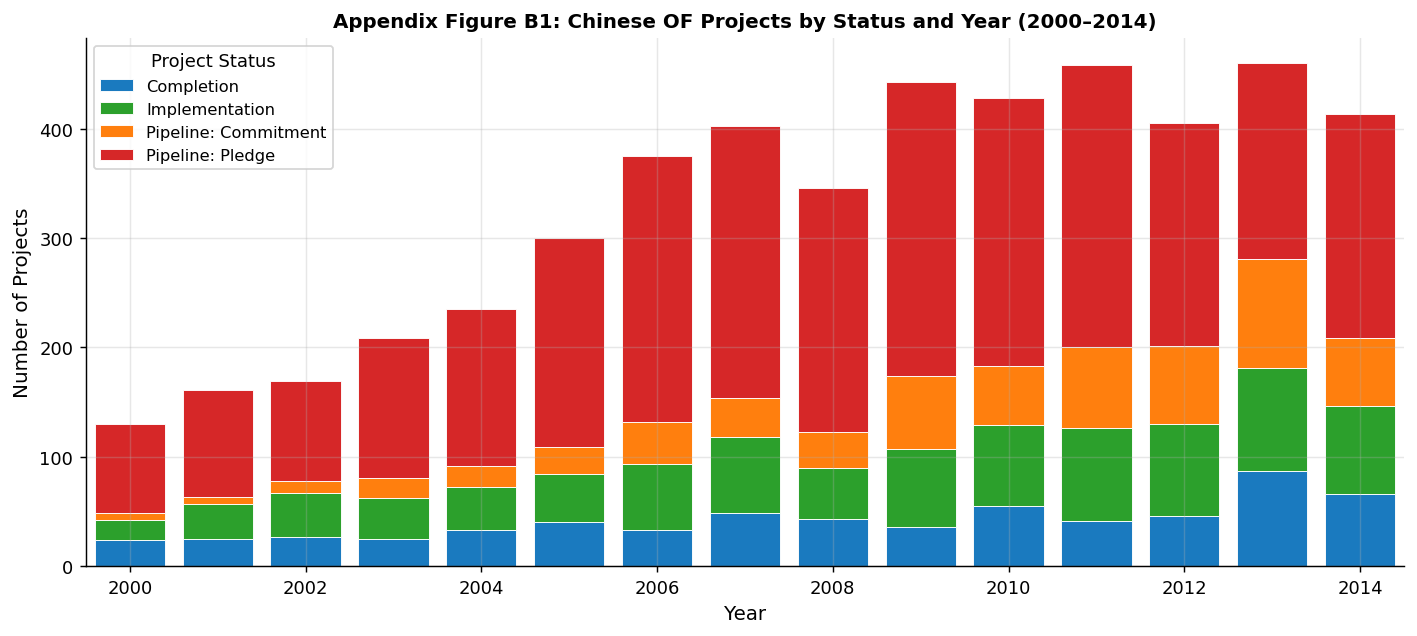

Appendix Figure B1 displayed.


In [13]:
STATUS = {1: 'Completion', 2: 'Implementation',
          3: 'Pipeline: Commitment', 4: 'Pipeline: Pledge'}
SCLR   = {1: '#1a7abf', 2: '#2ca02c', 3: '#ff7f0e', 4: '#d62728'}

piv = proj.pivot_table(index='year', columns='status_code',
                        values='n_projects', fill_value=0)
fig, ax = plt.subplots(figsize=(11, 5))
bot = np.zeros(len(piv))
for sc in sorted(piv.columns):
    v = piv[sc].values
    ax.bar(piv.index, v, bottom=bot, color=SCLR.get(sc, 'gray'),
           label=STATUS.get(sc, f'Status {int(sc)}'),
           edgecolor='white', lw=0.5)
    bot += v
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Number of Projects', fontsize=11)
ax.set_title('Appendix Figure B1: Chinese OF Projects by Status and Year (2000–2014)',
             fontsize=11, fontweight='bold')
ax.legend(title='Project Status', fontsize=9)
ax.set_xlim(1999.5, 2014.5)
plt.tight_layout()
plt.show()
print('Appendix Figure B1 displayed.')

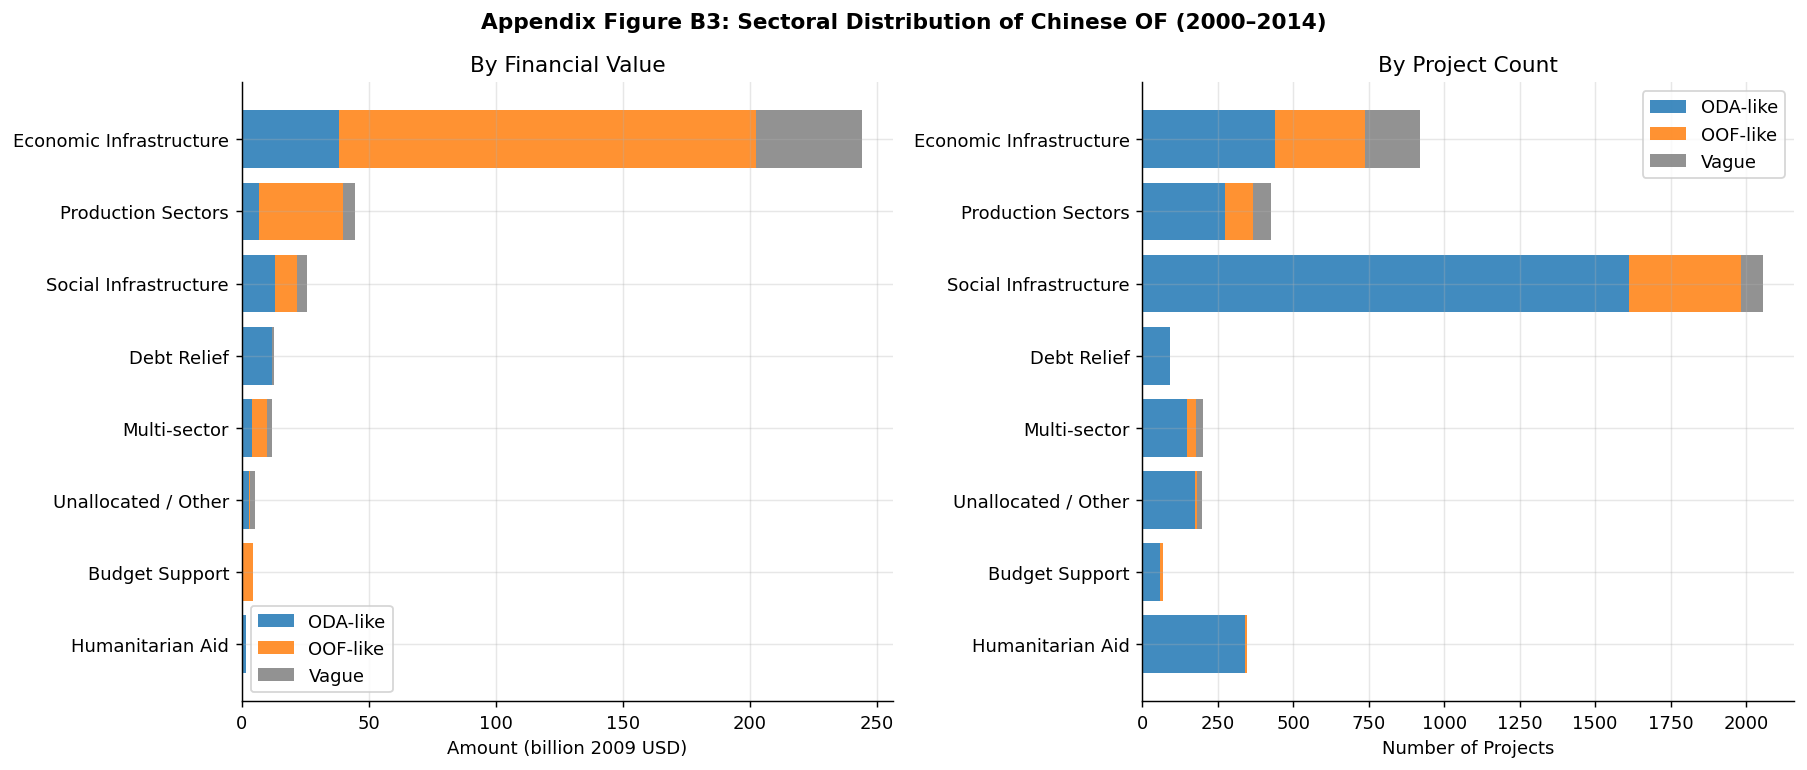

Appendix Figure B3 displayed.


In [14]:
def broad_sec(crs):
    if pd.isna(crs): return 'Unallocated / Other'
    c = int(crs)
    if   100 <= c < 200: return 'Social Infrastructure'
    elif 200 <= c < 300: return 'Economic Infrastructure'
    elif 300 <= c < 400: return 'Production Sectors'
    elif 400 <= c < 500: return 'Multi-sector'
    elif 500 <= c < 600: return 'Budget Support'
    elif 600 <= c < 700: return 'Debt Relief'
    elif 700 <= c < 800: return 'Humanitarian Aid'
    else:                return 'Unallocated / Other'

cdf_p = cdf.dropna(subset=['crs_sector']).copy()
cdf_p['crs_sector'] = pd.to_numeric(cdf_p['crs_sector'], errors='coerce')
cdf_p['broad'] = cdf_p['crs_sector'].apply(broad_sec)
cdf_p['flow_s'] = cdf_p['flow_class'].apply(
    lambda x: 'ODA-like' if 'ODA' in str(x) else ('OOF-like' if 'OOF' in str(x) else 'Vague'))
cdf_p['amount'] = pd.to_numeric(cdf_p['amount'], errors='coerce')
cdf_p['proj_count'] = pd.to_numeric(cdf_p['proj_count'], errors='coerce')

sec_amt = cdf_p.dropna(subset=['amount']).groupby(['broad','flow_s'])['amount'].sum().unstack(fill_value=0)
sec_cnt = cdf_p.groupby(['broad','flow_s'])['proj_count'].sum().unstack(fill_value=0)
sorted_idx = sec_amt.sum(axis=1).sort_values(ascending=True).index
sec_amt = sec_amt.loc[sorted_idx]
sec_cnt = sec_cnt.loc[sorted_idx]
CLR = {'ODA-like': '#1f77b4', 'OOF-like': '#ff7f0e', 'Vague': '#7f7f7f'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Appendix Figure B3: Sectoral Distribution of Chinese OF (2000–2014)',
             fontsize=12, fontweight='bold')
left1 = np.zeros(len(sec_amt))
left2 = np.zeros(len(sec_cnt))
for fc in ['ODA-like', 'OOF-like', 'Vague']:
    if fc in sec_amt.columns:
        ax1.barh(sec_amt.index, sec_amt[fc]/1e3, left=left1, label=fc, color=CLR[fc], alpha=0.85)
        left1 += sec_amt[fc].values/1e3
    if fc in sec_cnt.columns:
        ax2.barh(sec_cnt.index, sec_cnt[fc], left=left2, label=fc, color=CLR[fc], alpha=0.85)
        left2 += sec_cnt[fc].values
ax1.set_xlabel('Amount (billion 2009 USD)'); ax1.set_title('By Financial Value'); ax1.legend()
ax2.set_xlabel('Number of Projects');        ax2.set_title('By Project Count');    ax2.legend()
plt.tight_layout()
plt.show()
print('Appendix Figure B3 displayed.')

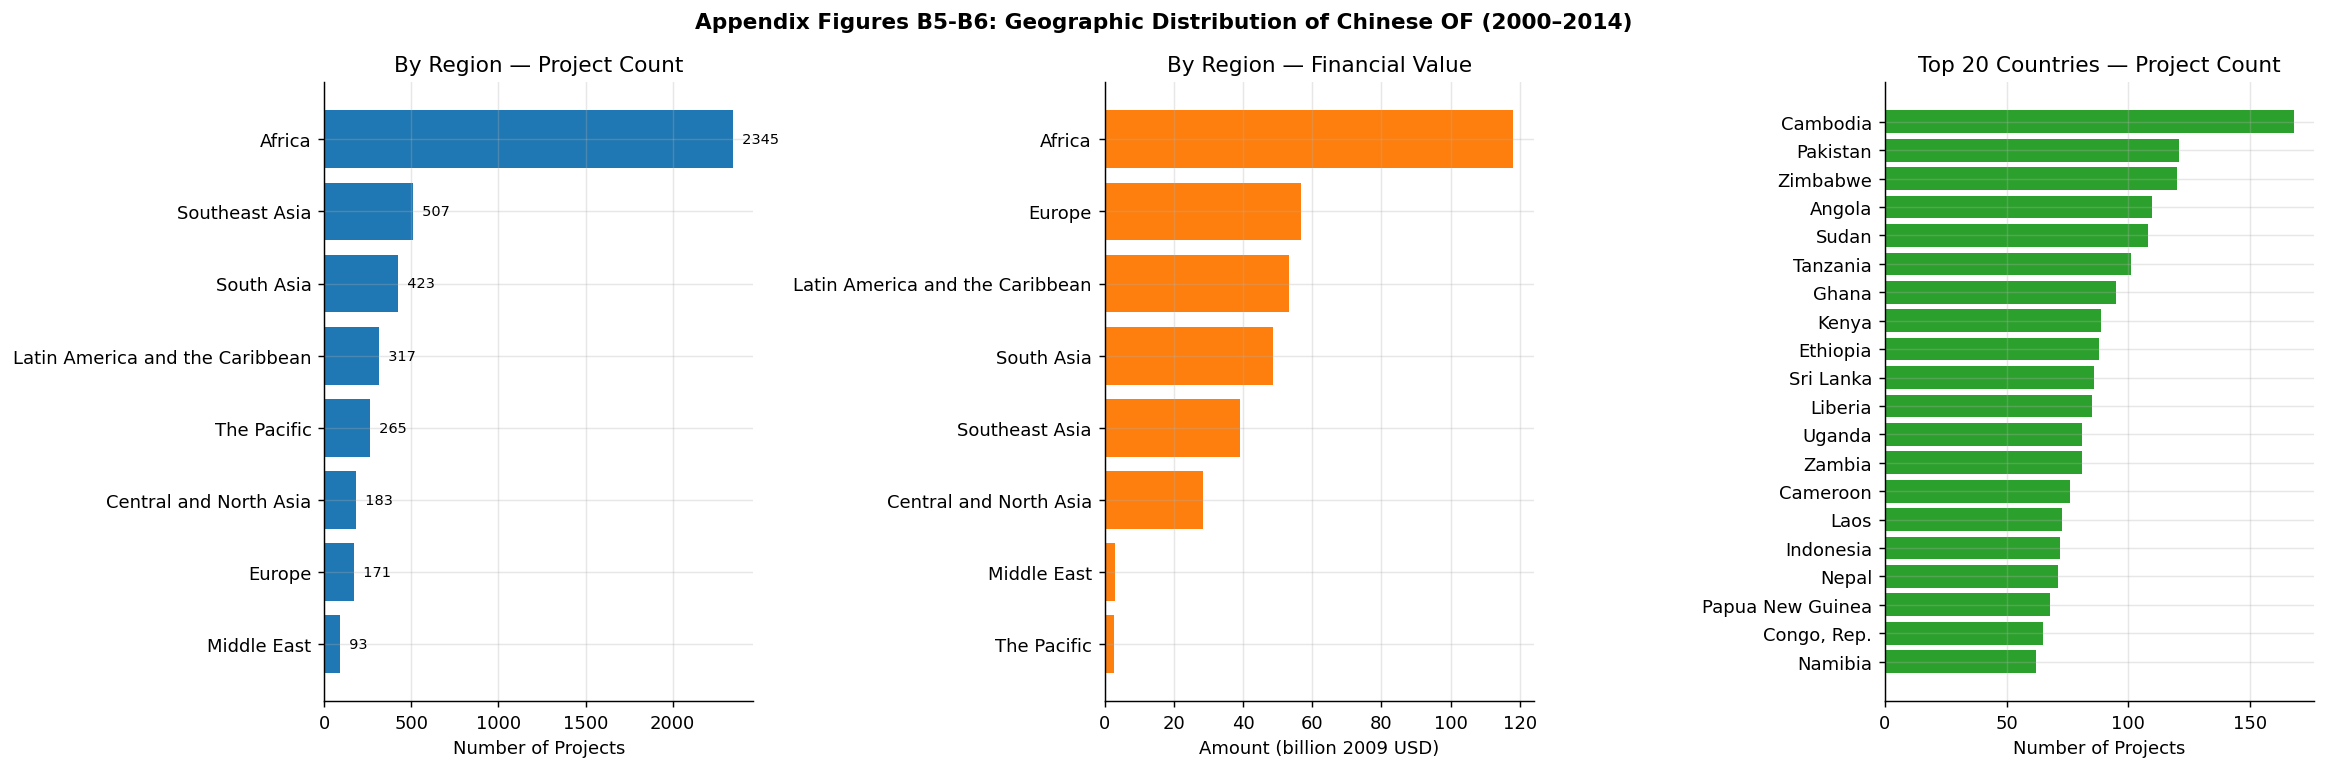

Appendix Figures B5-B6 displayed.


In [15]:
cdf['proj_count'] = pd.to_numeric(cdf['proj_count'], errors='coerce')
region_cnt = cdf.groupby('region')['proj_count'].sum().sort_values(ascending=True)
region_amt = cdf.dropna(subset=['amount']).groupby('region')['amount'].sum().sort_values(ascending=True)
top20      = cdf.groupby('recipient')['proj_count'].sum().sort_values(ascending=False).head(20)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Appendix Figures B5-B6: Geographic Distribution of Chinese OF (2000–2014)',
             fontsize=12, fontweight='bold')

axes[0].barh(region_cnt.index, region_cnt.values, color='#1f77b4')
axes[0].set_xlabel('Number of Projects')
axes[0].set_title('By Region — Project Count')
for i, (r, v) in enumerate(zip(region_cnt.index, region_cnt.values)):
    axes[0].text(v, i, f'  {int(v)}', va='center', fontsize=8)

axes[1].barh(region_amt.index, region_amt.values/1e3, color='#ff7f0e')
axes[1].set_xlabel('Amount (billion 2009 USD)')
axes[1].set_title('By Region — Financial Value')

axes[2].barh(top20.index[::-1], top20.values[::-1], color='#2ca02c')
axes[2].set_xlabel('Number of Projects')
axes[2].set_title('Top 20 Countries — Project Count')

plt.tight_layout()
plt.show()
print('Appendix Figures B5-B6 displayed.')